In [1]:
# import standard packages
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask
from pathlib import Path
import dask.dataframe as dd
import cmocean
import xesmf as xe
import seaborn as sns
# import spatial packages
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray as rio
import seaborn as sns
import xarray as xr
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from dask.distributed import Client
from google.cloud import storage
import xskillscore as xs

try:
    import flox
except ImportError:
    print("[ACTEA_downscale] Warning: flox not installed - continuing without")

import sys
sys.path.append('../')
import ACTEA_gcs
import ACTEA_merge_datasets

In [2]:
# Settings for the script
sns.set_style("white")
actea_variables = ["uas","vas"]
time="2018-01-01"
coarsen_step = 1
lat_lon_ext = [-173., -152., 54., 68.]
depth=20.0
frequency="daily"
base_path=f"era5_validation/"
gcs = ACTEA_gcs.ACTEA_gcs(frequency)
gcs.setup_actea_google_storage()
if not Path(base_path).exists():
    Path(base_path).mkdir(parents=True)

### Load the Ba+SD downscaled ERA5 data
Load the final dataset after downscaling the coarsened ERA5 dataset.

In [3]:
ds_all_actea={}
for varname, iterations in zip(actea_variables, [0,0]):
    ds_all_actea[varname], ds_plotfile = ACTEA_merge_datasets.create_merged_ds(["test_era5"], 
                                                            "ERA5",  
                                                            "surface", 
                                                            varname, 
                                                            "ssp585", 
                                                            "r1i1p1f1", 
                                                            depth,
                                                            iterations=iterations,
                                                            frequency=frequency)
    print(f"ACTEA: {varname} dataset size in MB", ds_all_actea[varname][varname].size / (1024*1024))
    
ds_uo_actea = ds_all_actea["uas"].sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))
ds_vo_actea = ds_all_actea["vas"].sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))

[ACTEA_merge_datasets] ssp585 uas (10227, 89, 109)
ACTEA: uas dataset size in MB 94.61605739593506
[ACTEA_merge_datasets] ssp585 vas (10227, 89, 109)
ACTEA: vas dataset size in MB 94.61605739593506


In [ ]:
import matplotlib.colors as mcolors
def plot_map_era5_or_actea_on_standard_grid(varname, da: xr.DataArray, 
                                            lat_lon_ext, year="2015-2020", 
                                            producer="ACTEA", vmin=-0.2, 
                                            vmax=0.2, cmap="RdBu_r"):
    
    fig = plt.figure(figsize=[18,4])
    cmap = cmocean.cm.balance
    if varname in ["LSE_uas", "LSE_vas", "LSE"]:
        cmap = "RdYlBu_r"
     
    ax = fig.add_subplot(projection= ccrs.PlateCarree(central_longitude=0),facecolor='ghostwhite')
    da.plot(y='lat',x='lon', 
                            ax=ax,
                vmin=vmin, vmax=vmax, extend='both',
                cmap=cmap, add_colorbar=True)

    land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                            edgecolor='face',
                                            facecolor='ghostwhite')

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    # Customize the gridlines and tick labels
    gl.top_labels = False      # Changed from gl.xlabels_top
    gl.right_labels = False    # Changed from gl.ylabels_right
    gl.left_labels = True      # Add this for consistency
    gl.bottom_labels = True    # Add this for consistency
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    ax.coastlines()
  #  ax.add_feature(land_10m)
  #  ax.add_feature(cfeature.COASTLINE)
    ax.gridlines(color='black', alpha=0.5, linestyle='--')
    ax.set_extent(lat_lon_ext, crs=ccrs.PlateCarree())
    #plt.title(f"{producer} grid {varname} 2015-2020")
    plt.savefig(f"{base_path}/{producer}_{varname}_2015-2020.png", dpi=200, bbox_inches='tight', facecolor='w')
    plt.show()

### Load the original ERA5 dataset
This dataset is stored from 1993 to 2019. The dataset is stored in the form of a netCDF file. The dataset
is generated and upload to GCS automatically when you run the downscaling using 'ERA5' as the model. This dataset is
then coarsened and used as the input for the downscaling process. 

In [5]:
def load_era5_datasets():
    ds_uo = gcs.open_dataset_on_gs(f"downscaling_daily/test_era5/ssp585/ERA5/uas/ERA5_r1i1p1f1_uas_surface_{depth}m_ERA5_full.nc", engine="h5netcdf")
    ds_vo = gcs.open_dataset_on_gs(f"downscaling_daily/test_era5/ssp585/ERA5/vas/ERA5_r1i1p1f1_vas_surface_{depth}m_ERA5_full.nc", engine="h5netcdf")
    return ds_uo.sel(time=slice("2015-01-01","2021-01-01")).sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3])), ds_vo.sel(time=slice("2015-01-01","2021-01-01")).sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))

ds_uo_era5, ds_vo_era5 = load_era5_datasets()
ds_uo_era5 = ds_uo_era5.resample(time="1M").mean()
ds_vo_era5 = ds_vo_era5.resample(time="1M").mean()

print("ERA5 fine uas size in MB", ds_uo_era5.uas.size / (1024*1024))
print("ERA5 fine vas size in MB", ds_vo_era5.vas.size / (1024*1024))
print(f"Time range: {ds_uo_era5.time.min().values} to {ds_uo_era5.time.max().values}")


ERA5 fine uas size in MB 0.33267974853515625
ERA5 fine vas size in MB 0.33267974853515625
Time range: 2015-01-31T00:00:00.000000000 to 2020-12-31T00:00:00.000000000


/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [6]:
def load_coarsened_era5_datasets():
    ds_uo_coarse = gcs.open_dataset_on_gs(f"downscaling_daily/test_era5/ssp585/ERA5/uas/ERA5_r1i1p1f1_uas_surface_{depth}m_ERA5_coarsened_step_12.nc", engine="h5netcdf")
    ds_vo_coarse = gcs.open_dataset_on_gs(f"downscaling_daily/test_era5/ssp585/ERA5/vas/ERA5_r1i1p1f1_vas_surface_{depth}m_ERA5_coarsened_step_12.nc", engine="h5netcdf")
    return ds_uo_coarse.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3])), ds_vo_coarse.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))

ds_uo_coarse, ds_vo_coarse = load_coarsened_era5_datasets()
ds_vo_coarse = ds_vo_coarse.sel(time=slice("2015-01-01","2021-01-01"), lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3])).chunk({"time":-1, "lat":-1, "lon": -1})
ds_uo_coarse = ds_uo_coarse.sel(time=slice("2015-01-01","2021-01-01"), lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3])).chunk({"time":-1, "lat":-1, "lon": -1})
ds_uo_coarse = ds_uo_coarse.resample(time="1M").mean()
ds_vo_coarse = ds_vo_coarse.resample(time="1M").mean()

print("ERA5 coarse uas size in MB", ds_uo_coarse.uas.size / (1024*1024))
print("ERA5 coarse vas size in MB", ds_vo_coarse.vas.size / (1024*1024))
print(f"Time range: {ds_uo_coarse.time.min().values} to {ds_uo_coarse.time.max().values}")

ERA5 coarse uas size in MB 0.00240325927734375
ERA5 coarse vas size in MB 0.00240325927734375
Time range: 2015-01-31T00:00:00.000000000 to 2020-12-31T00:00:00.000000000


/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


### Plot the datasets to see the original data
We plot the úo´and ´vo´ variables to see the original data.

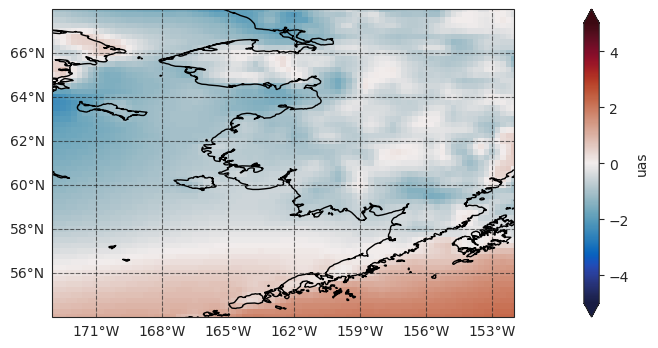

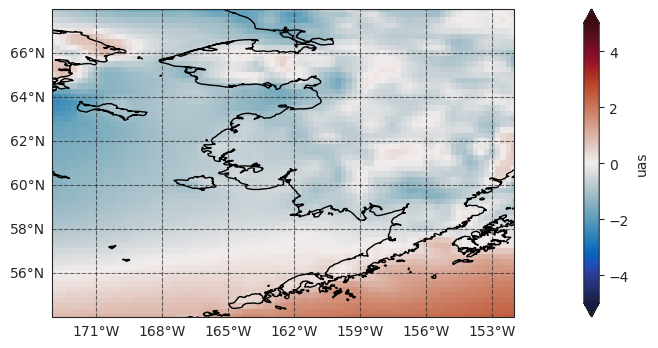

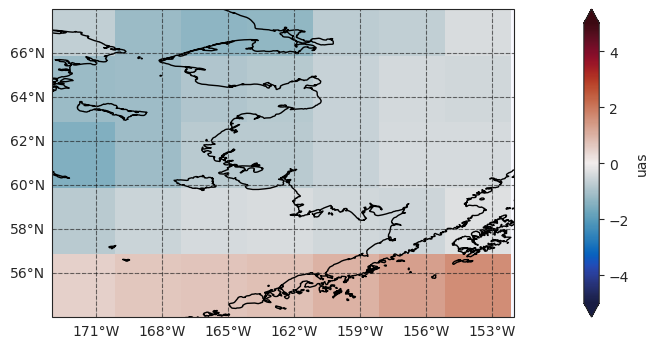

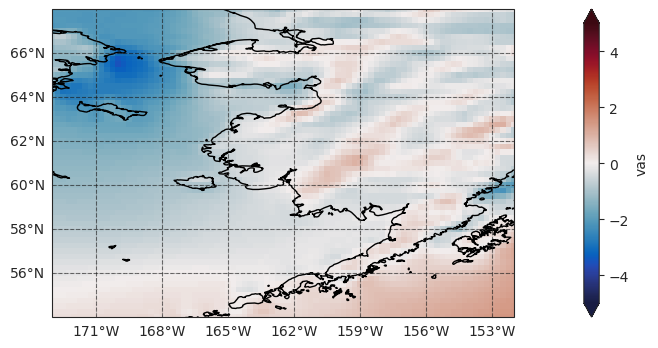

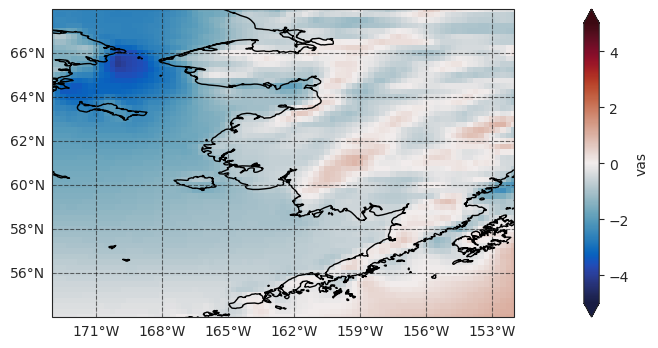

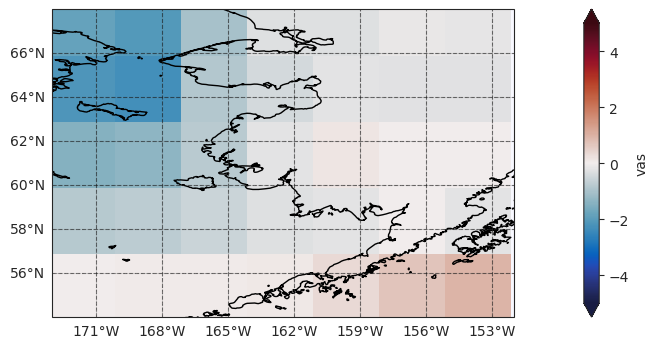

In [7]:
for varname, ds, name in zip(["uas","uas", "uas"], [ds_uo_era5, ds_uo_actea, ds_uo_coarse], ["ERA5", "ACTEA", "COARSE"]):
   plot_map_era5_or_actea_on_standard_grid(varname,  ds[varname].mean(dim="time"), lat_lon_ext, year=time, producer=name, vmin=-5, vmax=5)

for varname, ds, name in zip(["vas","vas", "vas"], [ds_vo_era5, ds_vo_actea, ds_vo_coarse], ["ERA5", "ACTEA", "COARSE"]):
   plot_map_era5_or_actea_on_standard_grid(varname,  ds[varname].mean(dim="time"), lat_lon_ext, year=time, producer=name, vmin=-5, vmax=5)

In [8]:
# uo
ds_uo_era5=ds_uo_era5.sel(time=slice("2015-01-01","2021-01-01"), lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3])).chunk({"time":-1, "lat":-1, "lon": -1})
ds_uo_actea= ds_uo_actea.sel(time=slice("2015-01-01","2021-01-01"), lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3])).chunk({"time":-1, "lat":-1, "lon": -1})
ds_uo_era5 = ds_uo_era5.resample(time="1M").mean()
ds_uo_actea = ds_uo_actea.resample(time="1M").mean()

# vo
ds_vo_era5=ds_vo_era5.sel(time=slice("2015-01-01","2021-01-01"), lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3])).chunk({"time":-1, "lat":-1, "lon": -1})
ds_vo_actea= ds_vo_actea.sel(time=slice("2015-01-01","2021-01-01"), lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3])).chunk({"time":-1, "lat":-1, "lon": -1})
ds_vo_era5 = ds_vo_era5.resample(time="1M").mean()
ds_vo_actea = ds_vo_actea.resample(time="1M").mean()


/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


### Weight according to latitude and calculate speed
We use scalar speed as our correlation metric.

In [9]:
# make weights as cosine of the latitude and broadcast
weights = np.cos(np.deg2rad(ds_vo_actea.lat))

ds_era5_speed=np.sqrt(ds_uo_era5.uas**2 + ds_vo_era5.vas**2)
ds_actea_speed=np.sqrt(ds_uo_actea.uas**2 + ds_vo_actea.vas**2)

ds_era5_speed_coarse = ds_era5_speed.coarsen(lat=coarsen_step, lon=coarsen_step, boundary="pad").mean()
ds_actea_speed_coarse = ds_actea_speed.coarsen(lat=coarsen_step, lon=coarsen_step, boundary="pad").mean()

### Calculate the Liu-mean efficiency score

LSE: Started calculating LSE


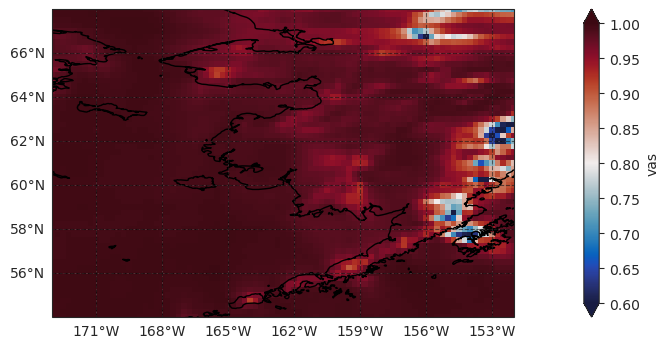

Average Liu-mean skill score vas: 0.9752882368129965
LSE: Started calculating LSE


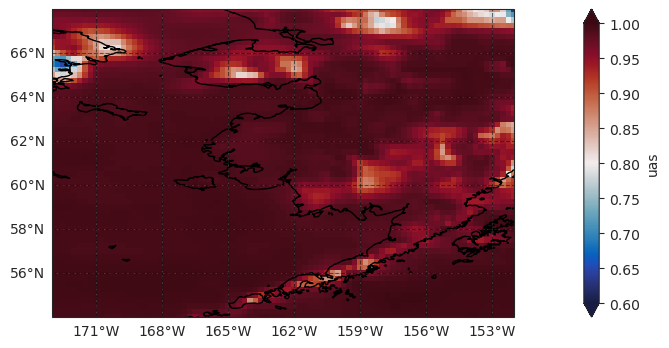

Average Liu-mean skill score uas: 0.9756181148704395


In [16]:
def liu_mean_efficiency_skill_score(ds_actea_speed_coarse, ds_era5_speed_coarse):
    """
    Liu-mean efficiency skill  score (LSE)
    • The ratio of the model mean over the mean of observations (alpha) which assessed the overall bias of the model  fields for each season;
    • The ratio of the model standard deviation over the standard deviation of observations (beta) which assessed the  overall spread of the model fields for each season;
    • The Pearson correlation coefficient (rho) of the spatial fields from the model and from the observations which  estimated the spatial mismatch of local features and bias.  
    
    A Liu skill score of 1 represents a perfect comparison with observations, while values below 1 indicate a  diminishing level of comparison between ensemble and observations. 
    """               
    
    ds_actea_speed_coarse_filtered = ds_actea_speed_coarse.where(ds_era5_speed_coarse.notnull())
    ds_era5_speed_coarse_filtered = ds_era5_speed_coarse.where(ds_actea_speed_coarse_filtered.notnull())

    print("LSE: Started calculating LSE")

    # Calculate spatial means
    mean_actea = ds_actea_speed_coarse_filtered.mean(dim="time", skipna=True)
    mean_era5 = ds_era5_speed_coarse_filtered.mean(dim="time", skipna=True)
    epsilon = 30.0 # to avoid problems around 0 we add a bias
    alpha = (mean_actea + epsilon) / (mean_era5 + epsilon)
     
    std_actea = ds_actea_speed_coarse_filtered.std(dim="time", skipna=True)
    std_era5 = ds_era5_speed_coarse_filtered.std(dim="time", skipna=True)

    beta = (std_actea + epsilon) / (std_era5 + epsilon)
    rho = xs.pearson_r(ds_era5_speed_coarse_filtered, ds_actea_speed_coarse_filtered, dim=["time"], skipna=True)
    
    return 1.0 - np.sqrt((rho*alpha - 1.0)**2 + (beta - 1.0)**2)

ds_vo_era5_vas_nan = ds_vo_era5.vas.where(ds_vo_era5.vas != np.nan)
ds_vo_actea_vas_nan = ds_vo_actea.vas.where(ds_vo_actea.vas != np.nan)

ds_uo_era5_uas_nan = ds_uo_era5.uas.where(ds_uo_era5.uas != np.nan)
ds_uo_actea_uas_nan = ds_uo_actea.uas.where(ds_uo_actea.uas != np.nan)

LSE = liu_mean_efficiency_skill_score(ds_vo_era5_vas_nan, ds_vo_actea_vas_nan)
plot_map_era5_or_actea_on_standard_grid("LSE_vas", LSE, lat_lon_ext, "liu_mean_vas_fine_2015_2020", vmin=0.6, vmax=1)
print(f"Average Liu-mean skill score vas: {LSE.mean(skipna=True).values}")

LSE  = liu_mean_efficiency_skill_score(ds_uo_era5_uas_nan, ds_uo_actea_uas_nan)
plot_map_era5_or_actea_on_standard_grid("LSE_uas", LSE, lat_lon_ext, "liu_mean_uas_fine_2015_2020", vmin=0.6, vmax=1)
print(f"Average Liu-mean skill score uas: {LSE.mean(skipna=True).values}")


In [ ]:
ds_actea_speed.sel(lat=55, lon=-167, method="nearest").plot(color="tab:red")
ds_era5_speed.sel(lat=55, lon=-167, method="nearest").plot(color="tab:blue")
plt.savefig(f"{base_path}/timeseries_speed_fine_2015_2020.png", dpi=200, bbox_inches='tight')